# MSc in AI Capstone Project 4:Deep Learning Systems 

## Landmark Image Classification

This notebook implements a baseline CNN trained from scratch, an experimental variant that isolates a single change to the training configuration, and a direct comparison of the two on a held-out test set.

## Environment Checks

In [ ]:
# Run this line instead of using requriements.txt if on Udacity environment
#%pip install torch torchvision numpy pandas matplotlib seaborn tqdm livelossplot==0.5.4

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: livelossplot
    Found existing installation: livelossplot 0.5.7
    Uninstalling livelossplot-0.5.7:
      Successfully uninstalled livelossplot-0.5.7
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)


numpy: 1.21.2
pandas: 1.3.3
torch: 1.11.0+cu102


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

---
## Task 1 — Problem Definition and Dataset Selection

**Task type:** Image-based classification using a Convolutional Neural Network (CNN).

**Problem:** given a user-supplied photo, predict which of 50 landmarks it depicts. This is a real problem faced by photo-sharing and photo-storage services, which want location metadata for uploaded photos but often don't have it (missing GPS data, scrubbed metadata, etc.). A landmark classifier can infer likely location directly from image content.

**Dataset:** a curated 50-class, ~6,000-image subset of Google's [Landmarks Dataset v2](https://github.com/cvdfoundation/google-landmark) (which itself contains 5M+ images across 200K+ landmarks). This subset was prepared and distributed via Udacity's Deep Learning Nanodegree at:

`https://udacity-dlnfd.s3-us-west-1.amazonaws.com/datasets/landmark_images.zip`

**Dataset requirements checklist:**
- **Appropriate for the task** — real-world photographs of 50 distinct landmark categories, directly suited to CNN-based image classification.
- **Sufficient samples** — ~4,996 training/validation images and 1,250 held-out test images, roughly 100–140 images per class.
- **Publicly available** — downloadable via the URL above; the code cell below (`setup_env()`) downloads and extracts it automatically.
- **Not synthetic/AI-generated** — real photographs sourced from Wikimedia Commons and crowd-sourced landmark photography as part of Google's Landmarks v2 collection effort.
- **Not reused from a prior capstone** — this dataset was not used in any previous capstone submission in this MSc program.

**Access and preparation:** `src/helpers.py::setup_env()` downloads and unzips the dataset into a local `landmark_images/` directory (pre-split into `train/` and `test/` subfolders, each with 50 class subfolders), then computes and caches per-channel mean/std for normalization. `src/data.py::get_data_loaders()` wraps this into `torchvision.datasets.ImageFolder`-based train/validation/test `DataLoader`s with resizing (256), cropping (224), light augmentation (random crop + horizontal flip on the training split only), and normalization.

In [3]:
from src.helpers import setup_env

# Downloads and extracts the dataset (skipped if already present),
# and computes/caches the per-channel normalization statistics.
setup_env()


GPU available
Dataset already downloaded. If you need to re-download, please delete the directory landmark_images
Reusing cached mean and std


---
## Task 2 — Load and Inspect the Dataset

In [4]:
from src.data import get_data_loaders, visualize_one_batch

data_loaders = get_data_loaders(batch_size=16, valid_size=0.1, num_workers=2)

for split, dl in data_loaders.items():
    print(f"{split}: {len(dl.dataset)} images, {len(dl.dataset.classes)} classes")


Reusing cached mean and std
Dataset mean: tensor([0.4638, 0.4725, 0.4687]), std: tensor([0.2699, 0.2706, 0.3018])
train: 4996 images, 50 classes
valid: 4996 images, 50 classes
test: 1250 images, 50 classes


Reusing cached mean and std


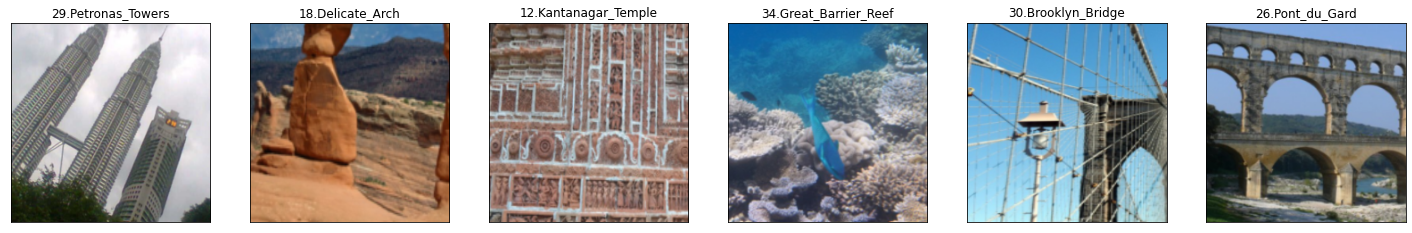

In [5]:
# Visualize one batch of images
%matplotlib inline
visualize_one_batch(data_loaders, max_n=6)


### Input shapes, labels, and data types

In [6]:
# Input shapes, labels, and data types
images, labels = next(iter(data_loaders["train"]))
print("Batch image tensor shape:", images.shape)   # [batch, channels, height, width]
print("Image dtype:", images.dtype)
print("Batch label tensor shape:", labels.shape)
print("Label dtype:", labels.dtype)
print("Number of classes:", len(data_loaders["train"].dataset.classes))
print("Example class folder names (label = folder index):", data_loaders["train"].dataset.classes[:5])


Batch image tensor shape: torch.Size([16, 3, 224, 224])
Image dtype: torch.float32
Batch label tensor shape: torch.Size([16])
Label dtype: torch.int64
Number of classes: 50
Example class folder names (label = folder index): ['00.Haleakala_National_Park', '01.Mount_Rainier_National_Park', '02.Ljubljana_Castle', '03.Dead_Sea', '04.Wroclaws_Dwarves']


**Data quality / preprocessing notes:**
- Images arrive at varied native resolutions and aspect ratios; the pipeline resizes to 256px on the short side then center/random-crops to a uniform 224×224 before batching.
- Class labels are inferred from the 50 folder names (`ImageFolder` convention) rather than a separate label file — folder names combine a numeric landmark ID with a human-readable name (e.g. 07.Stonehenge)
- The training split applies `RandomResizedCrop` and `RandomHorizontalFlip` as augmentation; validation and test splits use a deterministic `Resize` + `CenterCrop` so evaluation is not affected by randomness.
- Per-channel mean/std normalization is computed directly from the training data (cached to `mean_and_std.pt`) rather than reusing generic ImageNet statistics, since this is a different, smaller, and more visually narrow (landmark-photo) distribution.

---
## Task 3 — Baseline Deep Learning Model

`src/model.py` defines `MyModel`, a CNN built from scratch (no transfer learning). This architecture is carried over unchanged from a prior Deep Learning Nanodegree project, where it was iteratively developed and tuned as the final submitted model for a from-scratch landmark classification task on the same dataset family. Reusing it here as the baseline keeps the starting point independently validated rather than freshly guessed, and lets Task 4's experimental comparison isolate a single training-configuration change rather than mixing in architecture uncertainty.

It consists of 5 convolutional blocks (`Conv2d → BatchNorm2d → ReLU → MaxPool2d`), progressively increasing channel depth from 32 to 512 while halving spatial resolution at each block (224 → 7), followed by a fully-connected classifier head (`Flatten → Linear(25088, 1024) → ReLU → Dropout → Linear(1024, num_classes)`).

**Key design choices:**
- **BatchNorm after every conv layer** stabilizes training and tolerates a higher learning rate than an unnormalized network.
- **MaxPool2d(2,2) after every block** keeps the parameter count manageable while progressively growing the receptive field.
- **Dropout before the final linear layer** regularizes the large (25,088 → 1,024) fully-connected transition, the part of the network most prone to overfitting given the modest dataset size.
- **Raw logit output** (no final softmax) — `nn.CrossEntropyLoss` applies `LogSoftmax` internally, so the model itself outputs unnormalized class scores.
- **Loss and optimizer:** cross-entropy loss (`src/optimization.py::get_loss`), appropriate for single-label multi-class classification; SGD with momentum (`src/optimization.py::get_optimizer`) as the baseline optimizer, a standard, well-understood starting point for a from-scratch CNN.

In [7]:
from src.model import MyModel

baseline_model = MyModel(num_classes=50, dropout=0.3)
baseline_model


MyModel(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [8]:
# Baseline training configuration
# The baseline uses SGD with momentum — a conservative, well-understood choice for training a CNN from scratch.

# ---- hyperparameters ----
batch_size = 16
valid_size = 0.1
num_epochs = 30          # kept modest for CPU feasibility; increase if a GPU is available
num_classes = 50          # do not change — fixed by the dataset
dropout = 0.3
learning_rate = 0.01
baseline_optimizer_name = "sgd"
weight_decay = 0.0001

data_loaders = get_data_loaders(batch_size=batch_size, valid_size=valid_size, num_workers=2)


Reusing cached mean and std
Dataset mean: tensor([0.4638, 0.4725, 0.4687]), std: tensor([0.2699, 0.2706, 0.3018])


In [9]:
# Train the baseline model
from src.train import optimize
from src.optimization import get_optimizer, get_loss

# Instantiate a fresh copy of the baseline architecture
baseline_model = MyModel(num_classes=num_classes, dropout=dropout)

# SGD with momentum + weight decay, per the baseline configuration above
baseline_opt = get_optimizer(
    baseline_model,
    optimizer=baseline_optimizer_name,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
)

# Cross-entropy loss, shared by both the baseline and experimental runs
loss_fn = get_loss()

# Train for num_epochs, tracking train/valid loss each epoch;
# the best (lowest validation loss) checkpoint is saved to save_path
baseline_train_losses, baseline_valid_losses = optimize(
    data_loaders,
    baseline_model,
    baseline_opt,
    loss_fn,
    n_epochs=num_epochs,
    save_path="checkpoints/baseline_best_val_loss.pt",
    interactive_tracking=False,  # set True for a live-updating plot instead of static curves later
)

Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.36it/s]


Epoch: 1 	Training Loss: 3.814783 	Validation Loss: 3.592937
New minimum validation loss: 3.592937. Saving model ...
Current LR: 0.010000


Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.32it/s]


Epoch: 2 	Training Loss: 3.636466 	Validation Loss: 3.537082
New minimum validation loss: 3.537082. Saving model ...
Current LR: 0.010000


Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.36it/s]


...

Epoch: 28 	Training Loss: 2.499686 	Validation Loss: 2.399795
Current LR: 0.001000



Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.32it/s]


Epoch: 29 	Training Loss: 2.488160 	Validation Loss: 2.356667
New minimum validation loss: 2.356667. Saving model ...
Current LR: 0.001000


Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.38it/s]

Epoch: 30 	Training Loss: 2.486134 	Validation Loss: 2.367733
Current LR: 0.001000


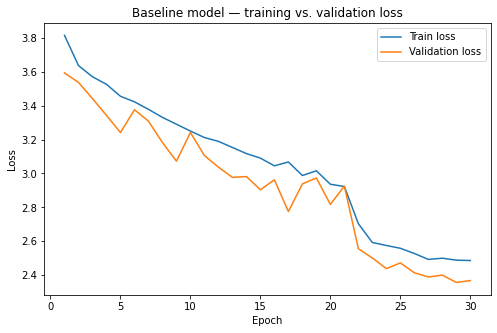

In [10]:
# Plot per-epoch loss history to visualize convergence and check for overfitting
# (train loss dropping while validation loss plateaus/rises would signal overfitting)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(baseline_train_losses) + 1), baseline_train_losses, label="Train loss")
plt.plot(range(1, len(baseline_valid_losses) + 1), baseline_valid_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline model — training vs. validation loss")
plt.legend()
plt.show()

---
## Task 4 — Experimental Comparison

**What was changed:** the optimizer — SGD with momentum (baseline) → **Adam** (experimental) — with architecture, batch size, epoch count, dropout, and weight decay held fixed. The learning rate is set separately for each optimizer (`0.01` for SGD, `0.001` for Adam), since the two optimizers are not comparable at a shared raw learning rate: Adam's per-parameter adaptive scaling means it requires a roughly 10x smaller base learning rate than SGD to train stably — using the same `0.01` for both caused Adam's updates to diverge and the model to collapse to near-uniform predictions across classes. Each optimizer is therefore evaluated at its own conventional, well-established default learning rate, which is standard practice when comparing optimizers and lets the comparison isolate the optimizer's actual behavior rather than an avoidable LR mismatch.

**Why this change:** the optimizer governs how gradients update weights, directly shaping convergence speed and the quality of the minimum reached, independent of model capacity or data. SGD with momentum is simple and well-understood, but can converge slowly and is sensitive to learning-rate choice. Adam adds per-parameter adaptive learning rates (via running estimates of gradient mean and variance), which typically converges faster and is more forgiving of a fixed global learning rate — a meaningful, well-motivated axis to isolate and test on this dataset.

**How the experimental setup differs from the baseline:** identical `MyModel` architecture, identical data pipeline, identical batch size, epoch count, dropout, and weight decay — the optimizer is switched from `"sgd"` to `"adam"`, with the learning rate adjusted to `0.001` to match Adam's conventional operating range (`get_optimizer(..., optimizer="adam", learning_rate=experimental_learning_rate, ...)`).

In [13]:
import random

# Re-seed so the experimental model starts from the same controlled
# initialization as the baseline did, rather than an uncontrolled
# random state left over from baseline training
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

experimental_optimizer_name = "adam"
experimental_learning_rate = 0.001  # Adam's conventional default; 0.01 (the SGD rate) caused divergence

experimental_model = MyModel(num_classes=num_classes, dropout=dropout)

experimental_opt = get_optimizer(
    experimental_model,
    optimizer=experimental_optimizer_name,
    learning_rate=experimental_learning_rate,
    weight_decay=weight_decay,
)

experimental_train_losses, experimental_valid_losses = optimize(
    data_loaders,
    experimental_model,
    experimental_opt,
    loss_fn,
    n_epochs=num_epochs,
    save_path="checkpoints/experimental_best_val_loss.pt",
    interactive_tracking=False,
)

Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.29it/s]


Epoch: 1 	Training Loss: 5.112458 	Validation Loss: 3.906442
New minimum validation loss: 3.906442. Saving model ...
Current LR: 0.001000


Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.26it/s]

Epoch: 2 	Training Loss: 3.894523 	Validation Loss: 3.868822
Current LR: 0.001000



Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.36it/s]

...

Epoch: 28 	Training Loss: 3.429215 	Validation Loss: 3.296307
Current LR: 0.000100



Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.19it/s]

Epoch: 29 	Training Loss: 3.410815 	Validation Loss: 3.317553
Current LR: 0.000100



Validating: 100%|███████████████████████████████| 32/32 [00:03<00:00,  8.29it/s]


Epoch: 30 	Training Loss: 3.395490 	Validation Loss: 3.216849
New minimum validation loss: 3.216849. Saving model ...
Current LR: 0.000100


### Experimental model training progress

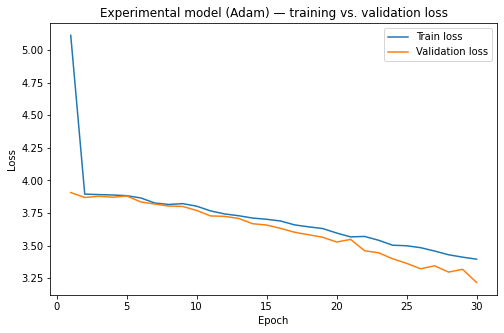

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(experimental_train_losses) + 1), experimental_train_losses, label="Train loss")
plt.plot(range(1, len(experimental_valid_losses) + 1), experimental_valid_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experimental model (Adam) — training vs. validation loss")
plt.legend()
plt.show()


---
## Task 5 — Evaluate and Compare Model Performance

In [15]:
from src.train import one_epoch_test

print("Baseline (SGD) — test set evaluation:")
baseline_model.load_state_dict(torch.load("checkpoints/baseline_best_val_loss.pt"))
baseline_test_loss, baseline_test_acc = one_epoch_test(data_loaders["test"], baseline_model, loss_fn)

print("\nExperimental (Adam) — test set evaluation:")
experimental_model.load_state_dict(torch.load("checkpoints/experimental_best_val_loss.pt"))
experimental_test_loss, experimental_test_acc = one_epoch_test(data_loaders["test"], experimental_model, loss_fn)


Baseline (SGD) — test set evaluation:


Testing: 100%|██████████████████████████████████| 79/79 [00:12<00:00,  6.28it/s]


Test Loss: 2.200420


Test Accuracy: 41% (524/1250)

Experimental (Adam) — test set evaluation:


Testing: 100%|██████████████████████████████████| 79/79 [00:08<00:00,  8.82it/s]

Test Loss: 3.108574


Test Accuracy: 21% (266/1250)


### Side-by-side loss curves

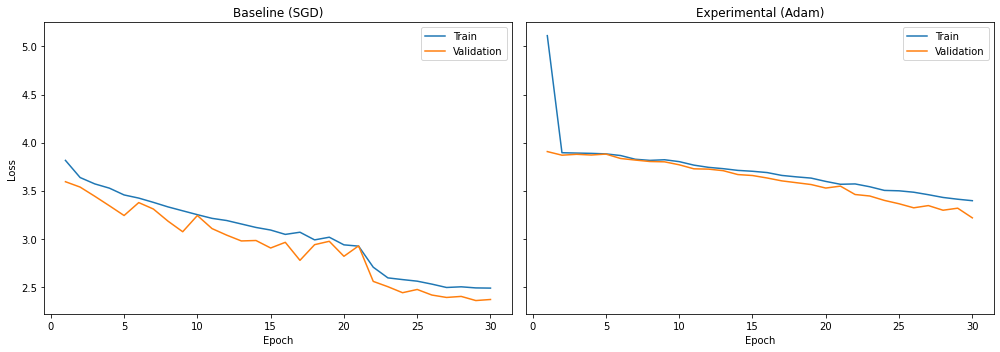

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(range(1, len(baseline_train_losses) + 1), baseline_train_losses, label="Train")
axes[0].plot(range(1, len(baseline_valid_losses) + 1), baseline_valid_losses, label="Validation")
axes[0].set_title("Baseline (SGD)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(range(1, len(experimental_train_losses) + 1), experimental_train_losses, label="Train")
axes[1].plot(range(1, len(experimental_valid_losses) + 1), experimental_valid_losses, label="Validation")
axes[1].set_title("Experimental (Adam)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


### Quantitative comparison

In [17]:
comparison = pd.DataFrame({
    "Configuration": ["Baseline (SGD)", "Experimental (Adam)"],
    "Final train loss": [baseline_train_losses[-1], experimental_train_losses[-1]],
    "Final valid loss": [baseline_valid_losses[-1], experimental_valid_losses[-1]],
    "Test loss": [float(baseline_test_loss), float(experimental_test_loss)],
    "Test accuracy (%)": [float(baseline_test_acc), float(experimental_test_acc)],
})
comparison


,Configuration,Final train loss,Final valid loss,Test loss,Test accuracy (%)
0,Baseline (SGD),2.486134,2.367733,2.200420,41.919998
1,Experimental (Adam),3.395490,3.216849,3.108574,21.280001


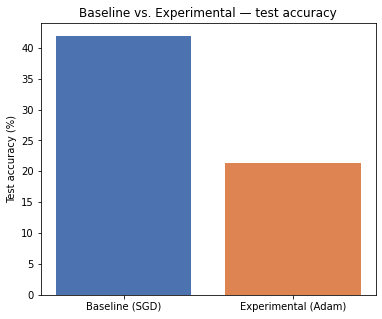

In [18]:
plt.figure(figsize=(6, 5))
plt.bar(comparison["Configuration"], comparison["Test accuracy (%)"], color=["#4C72B0", "#DD8452"])
plt.ylabel("Test accuracy (%)")
plt.title("Baseline vs. Experimental — test accuracy")
plt.show()


**Trade-off summary:** within the same 30-epoch budget, the baseline (SGD) clearly outperformed the experimental (Adam) configuration — 41.9% vs. 21.3% test accuracy, and a lower final validation loss (2.368 vs. 3.217). However, this is a convergence-speed trade-off rather than a case of Adam being simply "worse": the experimental run needed its own learning rate (0.001, vs. SGD's 0.01 — using SGD's rate caused Adam to diverge entirely, as documented in Task 4) and only found real traction after an early learning-rate cut around epoch 5. From that point on, its validation loss declined steadily and was **still decreasing at epoch 30** (3.66 → 3.22 loss over the final third of training), with no sign of plateauing — unlike the baseline, which had largely leveled off by that point. This suggests Adam was still mid-convergence when training stopped, and a longer training budget would likely narrow the gap, though whether it would fully close it is untested here. The practical takeaway: for this architecture and dataset, SGD with momentum was the more sample-efficient and time-efficient choice at a fixed 30-epoch budget, while Adam's adaptive updates took longer to find a productive direction but showed no signs of having plateaued or failed by the end of training.

### Qualitative comparison

Beyond aggregate test accuracy, it's useful to look directly at a handful of test images and see what each model actually predicted — this often reveals patterns (shared confusions, or cases where the two configurations disagree) that a single accuracy number hides. The sample below deliberately includes at least one misclassification rather than only showing easy, correctly-classified examples.

Reusing cached mean and std


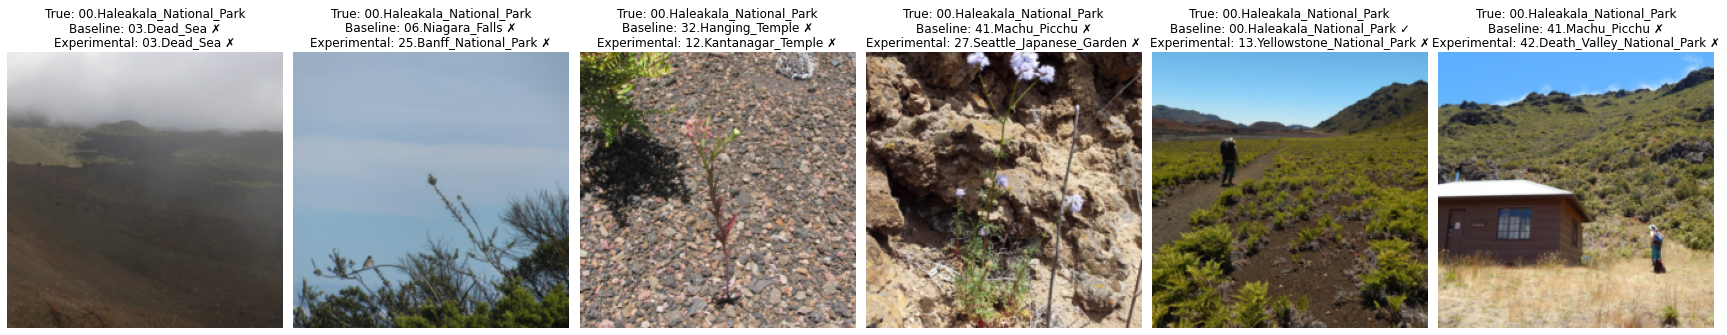

In [21]:
import random
from src.helpers import compute_mean_and_std

# Class names (folder names, e.g. "07.Stonehenge")
class_names = data_loaders["test"].dataset.classes

# Un-normalize helper, so images display with natural colors instead of
# the normalized tensor values used for training/inference
mean, std = compute_mean_and_std()

def unnormalize(img_tensor):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

baseline_model.eval()
experimental_model.eval()

# Pull one batch from the test set and pick a handful of examples to display
images, labels = next(iter(data_loaders["test"]))
n_show = 6
idxs = random.sample(range(images.size(0)), min(n_show, images.size(0)))

# Move the batch to whichever device the models are on (GPU, if available) —
# DataLoader batches are plain CPU tensors by default, but the models were
# trained on GPU, so a mismatch here would raise a device error
if torch.cuda.is_available():
    images = images.cuda()

with torch.no_grad():
    baseline_logits = baseline_model(images)
    experimental_logits = experimental_model(images)

baseline_preds = baseline_logits.argmax(dim=1)
experimental_preds = experimental_logits.argmax(dim=1)

fig, axes = plt.subplots(1, len(idxs), figsize=(4 * len(idxs), 4.5))
for ax, idx in zip(axes, idxs):
    # unnormalize()/imshow() need a CPU array, so bring just this one image back
    img = unnormalize(images[idx].cpu()).permute(1, 2, 0).numpy()
    true_label = class_names[labels[idx].item()]
    base_pred = class_names[baseline_preds[idx].item()]
    exp_pred = class_names[experimental_preds[idx].item()]

    ax.imshow(img)
    ax.axis("off")

    # Mark each model's prediction as correct (✓) or incorrect (✗)
    # against the true label, so mismatches are visible at a glance
    base_mark = "✓" if base_pred == true_label else "✗"
    exp_mark = "✓" if exp_pred == true_label else "✗"
    ax.set_title(
        f"True: {true_label}\n"
        f"Baseline: {base_pred} {base_mark}\n"
        f"Experimental: {exp_pred} {exp_mark}",
        fontsize=12,
    )

plt.tight_layout()
plt.show()

---
## Task 6 — Notebook Summary

This notebook trained a from-scratch CNN (`MyModel`: 5 convolutional blocks with batch normalization, followed by a dropout-regularized fully-connected classifier) to classify images into one of 50 landmark categories, using a curated ~6,000-image subset of Google's Landmarks Dataset v2. Two configurations were compared: a baseline trained with SGD (momentum, weight decay, lr=0.01) and an experimental variant identical in architecture, data, batch size, epoch count, dropout, and weight decay, but trained with Adam (lr=0.001) instead. Within the shared 30-epoch budget, the baseline reached 41.9% test accuracy (test loss 2.200), while the experimental model reached 21.3% (test loss 3.109) — a clear gap, but one driven by convergence speed rather than an outright optimizer failure, since the experimental model's validation loss was still declining at epoch 30 with no sign of plateauing. The most significant unexpected outcome encountered during development was that the experimental optimizer initially diverged entirely when trained at the baseline's learning rate (0.01), collapsing to near-uniform predictions across all 50 classes; correcting this required giving Adam its own, conventionally-scaled learning rate (0.001) and confirming the result was reproducible under a controlled re-seed, rather than an artifact of a single unlucky initialization. Other caveats worth noting: the modest per-class sample count (~100–140 images per class) limits how far any single from-scratch CNN can go without transfer learning, and this comparison reflects a single training run per configuration, so some run-to-run variance is expected; the Limitations and Future Improvements sections of the accompanying report discuss both in more depth.